сори удалил картинку изза нее юпитер лагал

# Основное домашнее задание №2  
## «Имитация отжига»

Это домашнее задание продолжает семинар **«Случайный поиск и Hill Climbing»**.

На семинаре были рассмотрены:

- случайное блуждание по пространству состояний;
- Hill Climbing, принимающий только улучшающие переходы;
- случайный поиск минимума функции;
- проблема локальных минимумов.

В домашнем задании предстоит реализовать **метод имитации отжига**. Он тоже переходит между соседними состояниями, но иногда разрешает временно ухудшить значение функции. Благодаря этому алгоритм способен выходить из некоторых локальных минимумов.

**Максимум за домашнее задание: 10 баллов.**


> ### Правила домашнего задания
>
> 1. Нельзя удалять существующие ячейки кода.
> 2. Можно добавлять и дописывать свои ячейки.
> 3. Место, куда нужно написать код, помечается комментарием `# Напиши код здесь`.
> 4. Ответ без кода, подтверждающего решение, не засчитывается, кроме теоретических вопросов.
> 5. Код должен запускаться последовательно с начала ноутбука.
> 6. Все графики должны иметь заголовок и подписи осей.
> 7. При использовании случайности необходимо фиксировать `seed`.


## Импорты и настройки


In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)


## Алгоритм имитации отжига

Пусть требуется минимизировать функцию

$f:\mathbb{R}^d\to\mathbb{R}.$

Алгоритм хранит текущую точку $x$ и генерирует соседнюю точку

$$
x' = x + \varepsilon,
$$

где $\varepsilon$ — случайный шаг.

Если новая точка лучше, переход принимается всегда. Если она хуже, переход всё равно может быть принят с вероятностью

$$
p=\exp\left(-\frac{\Delta f}{T}\right),
\qquad
\Delta f=f(x')-f(x)>0.
$$

Здесь $T>0$ называется **температурой**.

- При большой температуре ухудшающие переходы принимаются сравнительно часто.
- При маленькой температуре алгоритм становится более осторожным.
- Температура постепенно уменьшается, например:

$$
T_{k+1}=\alpha T_k,
\qquad 0<\alpha<1.
$$

### Связь с алгоритмами из семинара

- Как и случайное блуждание, метод использует случайные соседние состояния.
- Как и Hill Climbing, он предпочитает улучшения.
- В отличие от Hill Climbing, метод иногда принимает ухудшение и поэтому может покинуть локальный минимум.

### Псевдокод

```text
выбрать начальную точку x, температуру T и число шагов
best = x

повторить заданное число раз:
    сгенерировать соседнюю точку x_candidate
    вычислить delta = f(x_candidate) - f(x)

    если delta <= 0:
        принять x_candidate
    иначе:
        принять x_candidate с вероятностью exp(-delta / T)

    обновить best
    уменьшить температуру

вернуть best и историю поиска
```


## Задание 1 [1 балл]

Реализуй двумерную функцию Ackley:

$$
f(x,y)=
-20\exp\left(-0,2\sqrt{0,5(x^2+y^2)}\right)
-\exp\left(0,5\left(\cos(2\pi x)+\cos(2\pi y)\right)\right)
+e+20.
$$

Функция имеет глобальный минимум в точке $(0,0)$ со значением $0$ и большое количество локальных минимумов.

Проверь реализацию в точках $(0,0)$, $(1,0)$ и $(1,1)$.


In [65]:
def ackley(xy, a=20.0, b=0.2, c=2 * np.pi):
    # xy — массив из двух координат: [x, y]
    # ок, разверну их
    x, y = xy
    # Напиши код здесь
    # -20 * np.exp(-0.2*np.sqrt(0.5*(xy[0] * xy[0] + xy[1] * xy[1]))) - np.exp(0.5*(np.cos(2*np.pi*xy[0]) + np.cos(2 * np.pi * xy[1]))) + np.e + 20
    return (-a)*np.exp(-b*np.sqrt(0.5*(x**2 + y**2))) \
           - np.exp(0.5*(np.cos(c*x) + np.cos(c*y))) + np.e + a

print(ackley((0,0)))
print(ackley((1,0)))
print(ackley((1,1)))
ackley_vec = np.vectorize(ackley, signature='(n)->()')


0.0
2.637531092108304
3.6253849384403622


## Задание 2 [3,5 балла]

Реализуй метод имитации отжига для функции двух переменных.

Функция `simulated_annealing_2d` должна получать:

- `f` — минимизируемую функцию;
- `z0` — начальную точку;
- `T0` — начальную температуру;
- `alpha` — коэффициент охлаждения;
- `n_steps` — число итераций;
- `step_scale` — масштаб случайного шага;
- `bounds` — ограничения на координаты;
- `seed` — начальное состояние генератора случайных чисел.

На каждой итерации сделай следующее.

1. Сгенерируй кандидата
   $z'=z+\eta$, где $\eta$ имеет двумерное нормальное распределение.
2. При наличии границ верни координаты кандидата внутрь допустимой области с помощью `np.clip`.
3. Всегда принимай улучшение.
4. Ухудшение принимай с вероятностью
   $\exp(-(f(z')-f(z))/T)$.
5. Храни лучшую найденную точку отдельно от текущей.
6. Сохраняй историю:
   - текущие точки;
   - текущие значения функции;
   - лучшие найденные значения;
   - температуру;
   - факт принятия кандидата.

Функция должна вернуть:

```python
best_z, best_f, history
```


In [156]:
from typing import Callable

def simulated_annealing_2d(
    # def ackley(xy,        a=20.0, b=0.2, c=2 * np.pi):
    f: Callable[[np.ndarray], float],
    z0: np.ndarray,
    t0=1.0,
    alpha=0.995,
    n_steps=10_000,
    step_scale=0.5,
    bounds=None,
    seed=42,
):
    history = {
        "z": [],
        "f": [],
        "best_f": [],
        "T": [],
        "accepted": [],
    }
    history["z"].append(z0)
    history["f"].append(f(history["z"][-1]))
    history["best_f"].append(history["f"][-1])
    history["T"].append(t0)

    _best_z_f = (history["z"][-1], history["f"][-1])
    _last_accepted_z_f = (history["z"][-1], history["f"][-1])

    # Напиши код здесь
    rng = np.random.default_rng(seed)

    # Сначала сделал np.array([rng.normal(scale=step_scale, loc=0), rng.normal(scale=step_scale, loc=0)])
    # но потом нашлось что есть просто size=2
    for _ in range(n_steps):
        # шаг 1
        z_last, f_last = _last_accepted_z_f
        z_shift = z_last + rng.normal(size=2, scale=step_scale, loc=0)
        # шаг 2
        if bounds is not None: z_shift = np.clip(z_shift, *bounds)

        f_shift = f(z_shift)
        if f_shift <= f_last:
            # got better
            history["accepted"].append(True)
            _best_z_f = (z_last, f_last)
            _last_accepted_z_f = (history["z"][-1], history["f"][-1])
        else:
            # got worse
            if rng.random() < np.exp(
                    -(history["f"][-1] - f_last) / history["T"][-1]
            ):
                history["accepted"].append(True)
                _last_accepted_z_f = (history["z"][-1], history["f"][-1])
            else:
                history["accepted"].append(False)

        history["z"].append(z_shift)
        history["f"].append(f_shift)
        history["T"].append(history["T"][-1] * alpha)

    return _best_z_f, history


## Задание 3 [1 балл]

1. Построй контурный график функции Ackley на области
   $[-5,5]\times[-5,5]$ — **0,5 балла**.
2. По графику опиши особенности поверхности — **0,5 балла**.

В ответе укажи:

- где расположен глобальный минимум;
- почему задача может быть сложной для алгоритма, принимающего только улучшения.


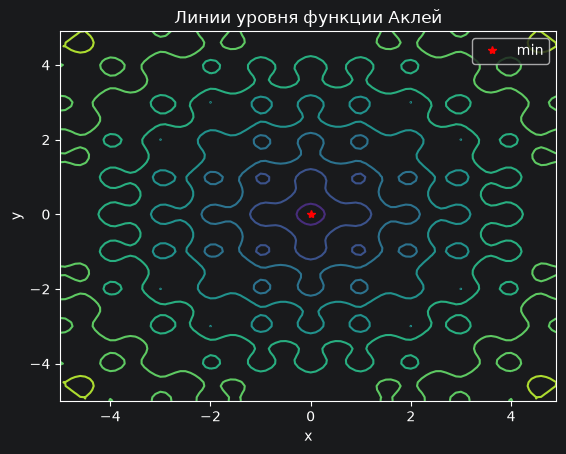

In [131]:
# Напиши код здесь
x, y = np.arange(-5, 5, 0.1), np.arange(-5, 5, 0.1)
# array([[[-5. , -5. ],
#         [-2.5, -5. ],
#         [ 0. , -5. ],
#         [ 2.5, -5. ],
#         [ 5. , -5. ]],
#
#        [[-5. , -2.5],
#         [-2.5, -2.5],
#         [ 0. , -2.5],
#         [ 2.5, -2.5],
#         [ 5. , -2.5]],
#            ......
z = ackley_vec(np.stack(np.meshgrid(x, y), axis=2))

row = np.argmin(np.min(z, axis=1))   # which row contains the min
col = np.argmin(z[row])              # which column in that row
min_x, min_y = x[col], y[row]
plt.contour(x, y, z)
plt.xlabel('x')
plt.ylabel('y')
plt.plot(min_x, min_y, 'r*', label="min")
plt.title("Линии уровня функции Аклей")
plt.legend()
plt.show()


#### Напиши текстовый ответ здесь.

Глобальный минимум расположен в точке 0 0

Задача может (и будет) сложной для алгоритма, принимающего только улучшения потому что функция имеет огромное количество локальных минимумов


## Задание 4 [1,5 балла]

Запусти метод имитации отжига из точки $(4,-4)$ в области
$[-5,5]\times[-5,5]$.

Используй параметры:

```python
T0 = 3.0
alpha = 0.995
n_steps = 40_000
step_scale = 0.6
seed = 7
```

1. Выведи лучшую найденную точку и значение функции.
2. Изобрази траекторию поиска на линиях уровня Ackley.
3. Построй два графика:
   - текущее значение $f(z_k)$;
   - лучшее найденное к шагу $k$ значение.
4. Вычисли долю принятых кандидатов.


(array([-0.00220968,  0.00444107]), np.float64(0.014685298435317407))


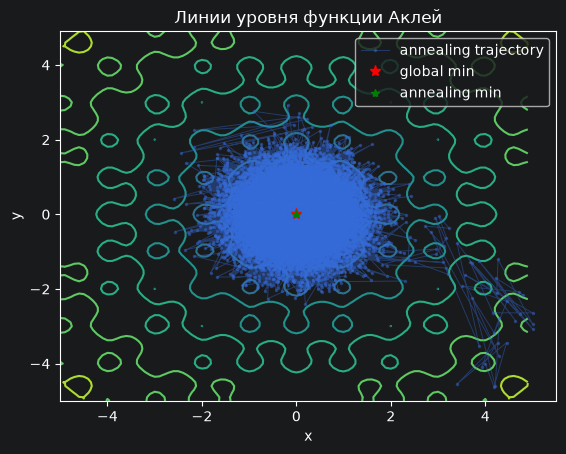

In [138]:
# Напиши код здесь
best_z_f, history = simulated_annealing_2d(ackley, np.array([4, -4]), 3.0, 0.995, 40_000, 0.6, (-5, 5))
print(best_z_f)

plt.contour(x, y, z)
plt.xlabel('x')
plt.ylabel('y')
plt.plot(
    np.array(history["z"])[:, 0],
    np.array(history["z"])[:, 1],
    '-o',
    markersize=1.5,
    linewidth=0.7,
    alpha=0.4,
    label="annealing trajectory"
)
plt.plot(min_x, min_y, 'r*', markersize='8', label="global min")
plt.plot(best_z_f[0][0], best_z_f[0][1], 'g*', label="annealing min")
plt.title("Линии уровня функции Аклей")
plt.legend()
plt.show()


## Случайный поиск из семинара

В последнем задании понадобится алгоритм `random_search`, реализованный на семинаре. Ниже приведена его готовая версия. Эту ячейку изменять не нужно.


In [69]:
def sample_point(bounds, rng):
    bounds = np.asarray(bounds, dtype=float)
    return rng.uniform(bounds[:, 0], bounds[:, 1])


def update_best(best_x, best_value, x, value):
    if value < best_value:
        return np.asarray(x).copy(), float(value)
    return best_x, best_value


def random_search(objective, bounds, n_iter=1_000, seed=42):
    if n_iter <= 0:
        raise ValueError("n_iter должно быть положительным")

    rng = np.random.default_rng(seed)

    points = []
    values = []
    best_history = []

    best_x = None
    best_value = np.inf

    for _ in range(n_iter):
        x = sample_point(bounds, rng)
        value = float(objective(x))

        points.append(x)
        values.append(value)

        best_x, best_value = update_best(
            best_x,
            best_value,
            x,
            value,
        )
        best_history.append(best_value)

    return {
        "best_x": np.asarray(best_x),
        "best_value": best_value,
        "points": np.asarray(points),
        "values": np.asarray(values),
        "best_history": np.asarray(best_history),
    }


## Задание 5 [3 балла]

### Часть A. Влияние параметров — 1,5 балла

Проведи не менее шести запусков метода имитации отжига. Меняй:

- начальную точку $z_0$;
- начальную температуру $T_0$;
- коэффициент охлаждения $\alpha$;
- масштаб шага `step_scale`.

Для каждого запуска сохрани:

- параметры;
- лучшую точку;
- лучшее значение функции;
- расстояние от лучшей точки до $(0,0)$;
- долю принятых кандидатов.

Меняй по одному параметру относительно базовой конфигурации, чтобы результат можно было интерпретировать.

### Часть B. Сравнение со случайным поиском — 1 балл

Сравни метод имитации отжига со случайным поиском из семинара.

Условия сравнения.

1. Оба метода должны иметь  — `2_000` новых точек.
2. Проведи `30` запусков с разными `seed`.
3. Для каждого метода вычисли:
   - медиану лучшего значения;
   - среднее лучшее значение;
   - долю запусков, в которых лучшая точка попала в круг
     $\lVert z\rVert\le 0,2$.

### Часть C. Вывод — 0,5 балла

Ответь на вопросы:

1. Какие параметры особенно сильно влияют на результат имитации отжига?
2. Что происходит при слишком быстром охлаждении?
3. Как различаются траектории случайного поиска и имитации отжига?
4. Какой метод оказался лучше в проведённом эксперименте?


In [153]:
# Напиши код здесь
experiments = [
    # блин ведь это первоначальное предназначение кортежей, передавать аргументы функции

    ("че у нас было изначально", "база", (ackley, np.array([4, -4]), 3.0, 0.995, 40_000, 0.6, (-5, 5))),
    ("другая стартовая точка", "далеко", (ackley, np.array([5, 5]), 3.0, 0.995, 40_000, 0.6, (-5, 5))),
    ("другая стартовая точка", "близко", (ackley, np.array([2, 2]), 3.0, 0.995, 40_000, 0.6, (-5, 5))),
    ("другая температура", "холодно", (ackley, np.array([4, -4]), 0.5, 0.995, 40_000, 0.6, (-5, 5))),
    ("другая температура", "горячо", (ackley, np.array([4, -4]), 5.0, 0.995, 40_000, 0.6, (-5, 5))),
    ("другой коэффициент охлаждения", "сильное охлаждение", (ackley, np.array([4, -4]), 3.0, 0.67, 40_000, 0.6, (-5, 5))),
    ("другой коэффициент охлаждения", "слабое охлаждение", (ackley, np.array([4, -4]), 3.0, 0.9995, 40_000, 0.6, (-5, 5))),
    ("другой маштаб шага", "маленький шаг", (ackley, np.array([4, -4]), 3.0, 0.67, 40_000, 0.1, (-5, 5))),
    ("другой маштаб шага", "большой шаг", (ackley, np.array([4, -4]), 3.0, 0.9995, 40_000, 1.0, (-5, 5))),
]
len(experiments)

9

In [158]:
results = [(title, subtitle, exp, simulated_annealing_2d(*exp)) for title, subtitle, exp in experiments]
assert len(results) == len(experiments)
len(results)

/tmp/ipykernel_630129/3233017359.py:49: RuntimeWarning: overflow encountered in exp
  if rng.random() < np.exp(
/tmp/ipykernel_630129/3233017359.py:50: RuntimeWarning: overflow encountered in scalar divide
  -(history["f"][-1] - f_last) / history["T"][-1]


9

In [168]:
import math
df_results = pd.DataFrame(results, columns=["title", "subtitle", "experiment", "result"])
df_results["dist"] = df_results["result"].apply(lambda r: math.dist(r[0][0], (0, 0)))
df_results.sort_values("dist")

,title,subtitle,experiment,result,dist
3,другая температура,холодно,"(<function ackley at 0x7f41245812d0>, [4, -4],...","(([-0.002760683983446828, -0.00050051118491022...",0.002806
6,другой коэффициент охлаждения,слабое охлаждение,"(<function ackley at 0x7f41245812d0>, [4, -4],...","(([-0.0037902829107553087, 0.00351854951210020...",0.005172
0,че у нас было изначально,база,"(<function ackley at 0x7f41245812d0>, [4, -4],...","(([-0.07898194277466825, -0.26905118369829756]...",0.280405
2,другая стартовая точка,близко,"(<function ackley at 0x7f41245812d0>, [2, 2], ...","(([-0.4188139394265551, 0.5043864420519589], 4...",0.655600
1,другая стартовая точка,далеко,"(<function ackley at 0x7f41245812d0>, [5, 5], ...","(([-0.4171300095268364, 0.5069298947518605], 4...",0.656487
4,другая температура,горячо,"(<function ackley at 0x7f41245812d0>, [4, -4],...","(([-0.4190390269155511, 0.5055310973408376], 4...",0.656624
5,другой коэффициент охлаждения,сильное охлаждение,"(<function ackley at 0x7f41245812d0>, [4, -4],...","(([-0.4198637400678194, 0.507823330514356], 4....",0.658916
8,другой маштаб шага,большой шаг,"(<function ackley at 0x7f41245812d0>, [4, -4],...","(([-0.7429556347303398, -0.5886126799240102], ...",0.947865
7,другой маштаб шага,маленький шаг,"(<function ackley at 0x7f41245812d0>, [4, -4],...","(([3.9825677796693046, -3.9833996524835147], 1...",5.632790


#### Напиши вывод здесь.
Ну мы видим, что эксперимент где мы выбрали холодную температуру был самым удачным
На втором месте слабое охлаждение, отставая всего в 2 раза (может быть погрешность
наибольшая ошибка у нас когда мы взяли маленький шаг, там вообще не попало. скорее всего там программа застряла в локальном минимуме и не смогла вылезти
